In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.spatial.distance as ssd

### Hierarchical Clustering

Instead of choosing **K** upfront, **Hierarchical Clustering** builds a **hierarchy** of clusters.

#### How It Works

| Approach | Description |
|----------|-------------|
| **Agglomerative (Bottom-Up)** | Start with each point as its own cluster, then merge the closest pairs step by step |
| **Divisive (Top-Down)** | Start with all points in one cluster, then split recursively |


#### Bottom-Up Approach (Agglomerative Clustering)

| Step | Action |
|------|--------|
| **Start** | Each point is its own cluster |
| **Step 1** | Merge the **closest pair** of clusters |
| **Step 2** | Merge the **next closest** pair |
| **...** | Continue merging |
| **End** | All points in one cluster |

**Result:** A **tree** (dendrogram) showing the merging history.


```mermaid
graph TD
    A1[Point 1] --- M1((Merge 1))
    A2[Point 2] --- M1
    M1 --- M3((Merge 3))
    
    A3[Point 3] --- M2((Merge 2))
    A4[Point 4] --- M2
    M2 --- M3
    
    M3 --- M5((Merge 5))
    
    A5[Point 5] --- M4((Merge 4))
    A6[Point 6] --- M4
    M4 --- M5
    
    M5 --- M7((Merge 7))
    
    A7[Point 7] --- M6((Merge 6))
    A8[Point 8] --- M6
    M6 --- M7
    
    M7 --- M8((Merge 8))
    
    A9[Point 9] --- M8
    A10[Point 10] --- M8

```

| Algorithm | Best For | When to Use |
|-----------|----------|-------------|
| **K-Means** | Large datasets, spherical clusters | Speed, known K |
| **Hierarchical** | Small datasets, interpretability | Unknown K, dendrogram |
    

### Linkage Methods
| Method | How It Works | Pros | Cons | Best For |
|--------|--------------|------|------|----------|
| **Ward** | Minimizes variance within clusters (minimizes sum of squared distances) | ✅ Compact, spherical clusters<br>✅ Similar to K-Means | ❌ Sensitive to outliers | **Default choice** — works well for most datasets |
| **Complete** | Maximum distance between clusters (farthest points) | ✅ Tight clusters<br>✅ Similar-sized clusters | ❌ Sensitive to outliers | When you want compact, well-separated clusters |
| **Average** | Average distance between all pairs of points | ✅ Balanced<br>✅ Less sensitive to outliers | ❌ Can be slow on large data | When data has outliers or noise |
| **Single** | Minimum distance between clusters (nearest points) | ✅ Handles non-spherical shapes<br>✅ Fast | ❌ Prone to chaining | When clusters have complex shapes (e.g., elongated, curved) |
| **Centroid** | Distance between cluster centroids | ✅ Good for well-separated clusters | ❌ Can produce inversions (non-monotonic) | When clusters are well-separated and spherical |
| **Median** | Distance between medians of clusters | ✅ Robust to outliers | ❌ Can produce inversions | When you have outliers and want robustness |
| **Weighted** | Weighted average distance (based on cluster size) | ✅ Handles unbalanced clusters | ❌ Less common | When clusters have very different sizes |

Ward:     ✅ Best for most cases

#### When to Use Each Method

| Method | When to Use | When NOT to Use |
|--------|-------------|-----------------|
| **Ward** | ✅ Most cases<br>✅ Data is relatively clean<br>✅ You want compact clusters | ❌ Data has many outliers<br>❌ Clusters are non-spherical |
| **Complete** | ✅ You want tight, similar-sized clusters<br>✅ Clusters are spherical | ❌ Data has outliers<br>❌ Clusters are elongated |
| **Average** | ✅ Data has outliers or noise<br>✅ You want a balanced approach | ❌ You need very compact clusters |
| **Single** | ✅ Clusters are non-spherical (elongated, curved)<br>✅ You want to explore natural structure | ❌ You need compact clusters<br>❌ Data is dense |
| **Centroid** | ✅ Clusters are well-separated<br>✅ You want centroid-based interpretation | ❌ Clusters overlap<br>❌ Data is noisy |
| **Median** | ✅ You have outliers<br>✅ You want robustness | ❌ You need compact clusters |
| **Weighted** | ✅ Clusters have very different sizes | ❌ Most other cases (less common) |


In [2]:
# Create 10 points with clear groups
np.random.seed(42)

# Group 1: Points around (0, 0)
group1 = np.random.normal(0, 0.3, (4, 2))

# Group 2: Points around (3, 3)
group2 = np.random.normal(3, 0.3, (3, 2))

# Group 3: Points around (6, 0)
group3 = np.random.normal(6, 0.3, (3, 2))

# Combine
X = np.vstack([group1, group2, group3])

print(f"Total points: {len(X)}")
print(f"Feature shape: {X.shape}")
print("\nData points:")
for i, point in enumerate(X):
    print(f"  Point {i+1}: {point.round(2)}")

Total points: 10
Feature shape: (10, 2)

Data points:
  Point 1: [ 0.15 -0.04]
  Point 2: [0.19 0.46]
  Point 3: [-0.07 -0.07]
  Point 4: [0.47 0.23]
  Point 5: [2.86 3.16]
  Point 6: [2.86 2.86]
  Point 7: [3.07 2.43]
  Point 8: [5.48 5.83]
  Point 9: [5.7  6.09]
  Point 10: [5.73 5.58]


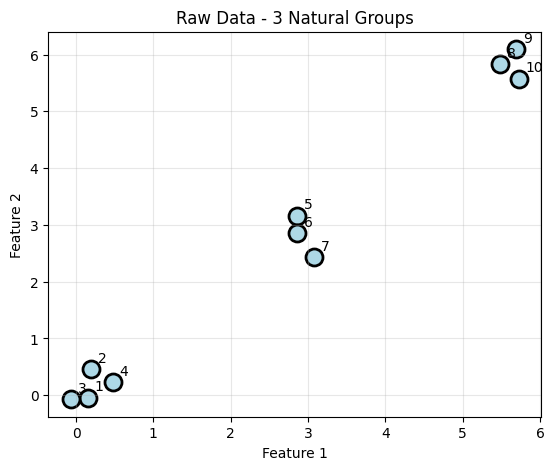

In [3]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=150, c='lightblue', edgecolors='black', linewidths=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Raw Data - 3 Natural Groups')
plt.grid(True, alpha=0.3)

for i, point in enumerate(X):
    plt.annotate(f'{i+1}', point, xytext=(5, 5), textcoords='offset points', fontsize=10)

In [29]:
print("\n" + "="*60)
print("STEP 1: COMPUTE DISTANCE MATRIX")
print("="*60)

# pairwise distances
distances = ssd.pdist(X, metric='euclidean')
print(distances)

# Convert to distance matrix
distance_matrix = ssd.squareform(distances)

print("Distance Matrix (Euclidean distances):")
print("Rows = Points, Columns = Points")
print("Values = Distance between points")
print(pd.DataFrame(distance_matrix).round(2))

# closest pair
np.fill_diagonal(distance_matrix, np.inf)
min_idx = np.unravel_index(np.argmin(distance_matrix), distance_matrix.shape)

print(f"Closest pair: Points {min_idx[0]} and {min_idx[1]}")
print(f"Distance: {distance_matrix[min_idx]:.2f}")
print(f"  Point {min_idx[0]+1}: {X[min_idx[0]].round(3)}")
print(f"  Point {min_idx[1]+1}: {X[min_idx[1]].round(3)}")


STEP 1: COMPUTE DISTANCE MATRIX
[0.50044204 0.22113865 0.42342469 4.19667466 3.9717682  3.82567904
 7.93322326 8.27152908 7.91707537 0.58980949 0.35983265 3.79777629
 3.58989087 3.48739017 7.53985924 7.87719337 7.53826983 0.62147393
 4.36276906 4.14487816 4.01356562 8.10318526 8.44112429 8.09311196
 3.78019583 3.55189275 3.40225874 7.51397493 7.85240941 7.49555024
 0.3024924  0.76704395 3.74208372 4.07949233 3.74874638 0.48308043
 3.96226694 4.30080624 3.94896269 4.17179153 4.5098998  4.11987773
 0.33879828 0.3536748  0.51891875]
Distance Matrix (Euclidean distances):
Rows = Points, Columns = Points
Values = Distance between points
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.50  0.22  0.42  4.20  3.97  3.83  7.93  8.27  7.92
1  0.50  0.00  0.59  0.36  3.80  3.59  3.49  7.54  7.88  7.54
2  0.22  0.59  0.00  0.62  4.36  4.14  4.01  8.10  8.44  8.09
3  0.42  0.36  0.62  0.00  3.78  3.55  3.40  7.51  7.85  7.50
4  4.20  3.80  4.36  3.78  0.00  0.30  0.77  3.74

In [34]:
print("\n" + "="*60)
print("STEP 2: BUILD CLUSTER HIERARCHY")
print("="*60)

# Compute linkage matrix
linkage_matrix = linkage(X, method='ward')

print("Linkage Matrix:")
print("Column 1: Cluster 1 ID")
print("Column 2: Cluster 2 ID")
print("Column 3: Distance at merge")
print("Column 4: Number of points in new cluster")
print("\n" + linkage_matrix.round(3).__str__())


STEP 2: BUILD CLUSTER HIERARCHY
Linkage Matrix:
Column 1: Cluster 1 ID
Column 2: Cluster 2 ID
Column 3: Distance at merge
Column 4: Number of points in new cluster

[[ 0.     2.     0.221  2.   ]
 [ 4.     5.     0.302  2.   ]
 [ 7.     8.     0.339  2.   ]
 [ 1.     3.     0.36   2.   ]
 [ 9.    12.     0.474  3.   ]
 [10.    13.     0.702  4.   ]
 [ 6.    11.     0.719  3.   ]
 [14.    16.     7.019  6.   ]
 [15.    17.    12.825 10.   ]]



STEP 3: VISUALIZE DENDROGRAM


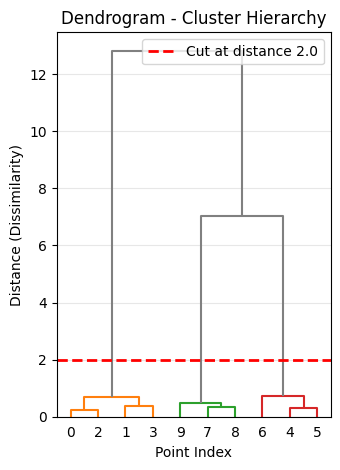


HOW TO READ THE DENDROGRAM:
  1. Each point starts as its own cluster (bottom)
  2. Points merge as they become more similar (moving up)
  3. Higher merges = more dissimilar clusters
  4. Red dashed line shows cut at distance 2.0
  5. Cut gives us 3 clusters!



In [35]:
print("\n" + "="*60)
print("STEP 3: VISUALIZE DENDROGRAM")
print("="*60)

plt.subplot(1, 2, 2)

dendrogram(
    linkage_matrix,
    orientation='top',
    color_threshold=2.0,    # color clusters below this distance
    above_threshold_color='gray',
    leaf_font_size=10
)

plt.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Cut at distance 2.0')
plt.xlabel('Point Index')
plt.ylabel('Distance (Dissimilarity)')
plt.title('Dendrogram - Cluster Hierarchy')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("""
HOW TO READ THE DENDROGRAM:
  1. Each point starts as its own cluster (bottom)
  2. Points merge as they become more similar (moving up)
  3. Higher merges = more dissimilar clusters
  4. Red dashed line shows cut at distance 2.0
  5. Cut gives us 3 clusters!
""")



STEP 4: CUT DENDROGRAM FOR DIFFERENT K


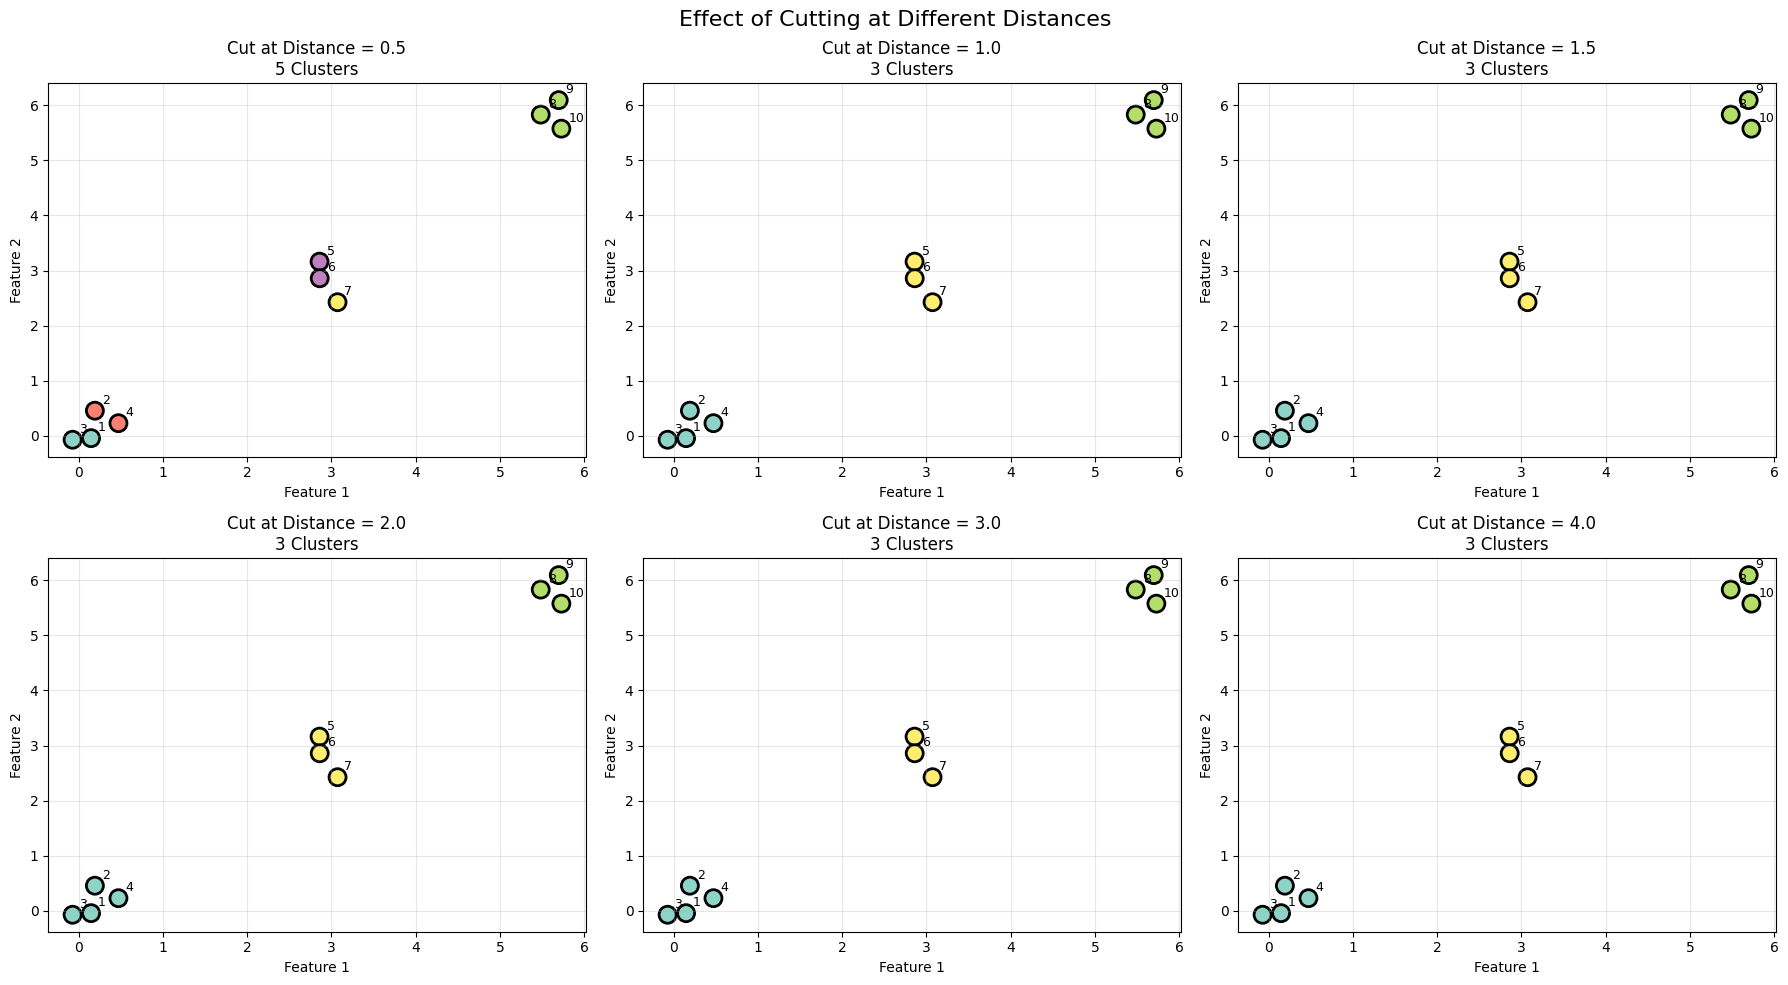

In [36]:
print("\n" + "="*60)
print("STEP 4: CUT DENDROGRAM FOR DIFFERENT K")
print("="*60)

# Cut at different distances
distances_to_try = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, d in enumerate(distances_to_try):
    # Cut the tree
    labels = fcluster(linkage_matrix, t=d, criterion='distance')
    n_clusters = len(set(labels))
    
    # Plot
    ax = axes[idx]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set3', s=150, edgecolors='black', linewidths=2)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Cut at Distance = {d}\n{n_clusters} Clusters')
    ax.grid(True, alpha=0.3)
    
    # Label points
    for i, point in enumerate(X):
        ax.annotate(f'{i+1}', point, xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.suptitle('Effect of Cutting at Different Distances', fontsize=16)
plt.tight_layout()
plt.show()


In [39]:
print("\n" + "="*60)
print("STEP 5: FINAL CLUSTERS (K=3)")
print("="*60)

# Get clusters by specifying number of clusters
labels_3 = fcluster(linkage_matrix, t=3, criterion='maxclust')

# AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_hc = hc.fit_predict(X)

results = pd.DataFrame({
    'Point': range(1, len(X)+1),
    'Feature1': X[:, 0],
    'Feature2': X[:, 1],
    'Cluster': labels_hc
})

print("Cluster Assignments:")
print(results.sort_values('Cluster').to_string(index=False))



STEP 5: FINAL CLUSTERS (K=3)
Cluster Assignments:
 Point  Feature1  Feature2  Cluster
     6  2.860975  2.860281        0
     7  3.072589  2.426016        0
     5  2.859158  3.162768        0
     1  0.149014 -0.041479        1
     4  0.473764  0.230230        1
     3 -0.070246 -0.070241        1
     2  0.194307  0.456909        1
     8  5.482525  5.831314        2
     9  5.696151  6.094274        2
    10  5.727593  5.576309        2


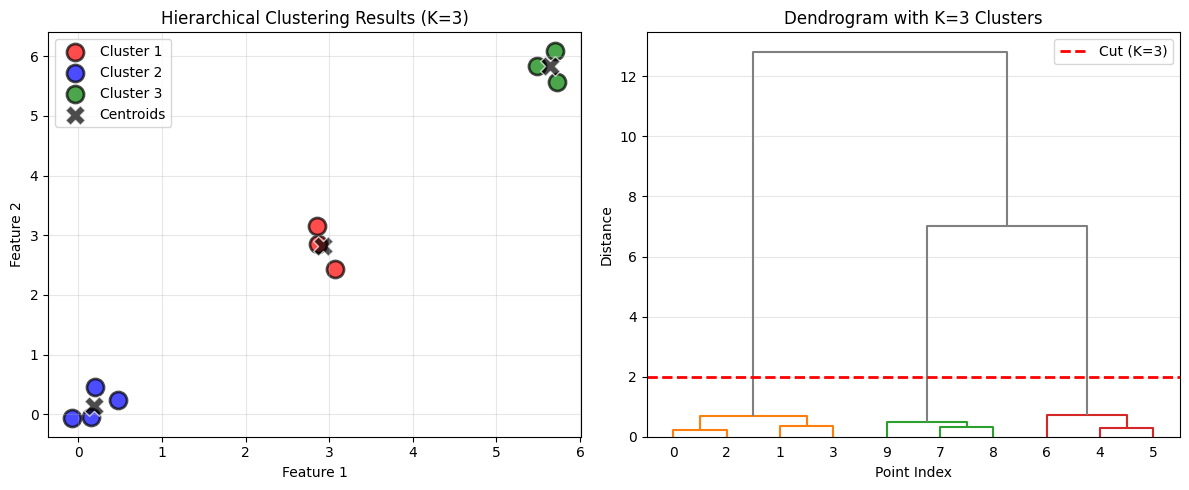

In [49]:
plt.figure(figsize=(12, 5))

# Plot 1: Clusters
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for i in range(3):
    mask = labels_hc == i
    plt.scatter(X[mask, 0], X[mask, 1], 
               c=colors[i], s=150, alpha=0.7, 
               edgecolors='black', linewidths=2,
               label=f'Cluster {i+1}')

# Get cluster centers
centers = np.array([X[labels_hc == i].mean(axis=0) for i in range(3)])
plt.scatter(centers[:, 0], centers[:, 1], 
           c='black', s=200, marker='X', 
           edgecolors='white', linewidths=1,
           label='Centroids', alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hierarchical Clustering Results (K=3)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Dendrogram with K=3 highlighted
plt.subplot(1, 2, 2)
dendrogram(
    linkage_matrix,
    color_threshold=2.0,
    above_threshold_color='gray',
    leaf_font_size=10
)


plt.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Cut (K=3)')
plt.xlabel('Point Index')
plt.ylabel('Distance')
plt.title('Dendrogram with K=3 Clusters')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### ✅ Advantages

| # | Advantage |
|---|-----------|
| 1 | **No need to specify K in advance** |
| 2 | **Dendrogram provides visual insight** |
| 3 | **Deterministic** (no random initialization) |
| 4 | **Works with any distance metric** |
| 5 | **Hierarchical relationships are interpretable** |

#### ❌ Disadvantages

| # | Disadvantage |
|---|--------------|
| 1 | **Computationally expensive** ($O(n^3)$) |
| 2 | **Not suitable for large datasets** |
| 3 | **Can't "undo" a merge** |
| 4 | **Sensitive to outliers** |


#### 💡 When to Use

| Condition | Why |
|-----------|-----|
| Small datasets (< 10,000 points) | Computationally feasible |
| Want to explore hierarchical relationships | Dendrogram shows structure |
| Don't know the number of clusters | No K needed upfront |
| Interpretability is important | Tree structure is easy to explain |


#### 💡 When NOT to Use

| Condition | Why |
|-----------|-----|
| Large datasets | Too slow ($O(n^3)$) |
| Speed is critical | K-Means is much faster |
| Clusters are not well-separated | May produce poor results |